Alles is nu gestandardiseerd op de absolute difference 

Question 1: “Which vocal features are most affected by different types and levels of perturbations?”
Apart scalen voor Original en apart scalen voor Wiener 

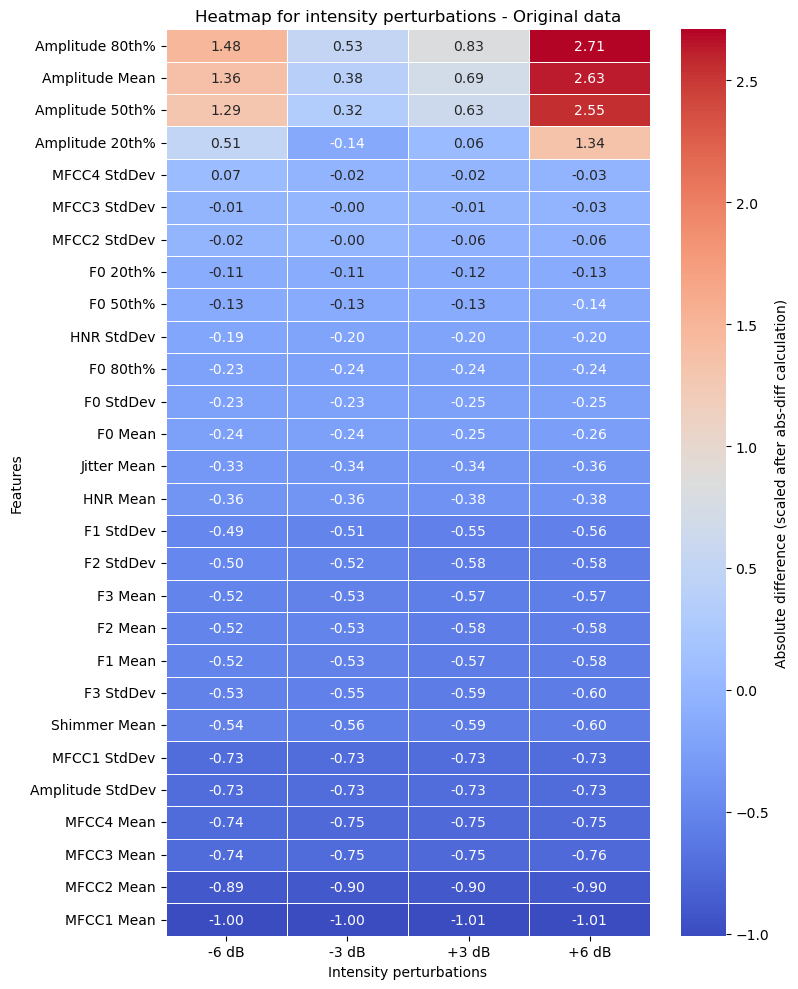

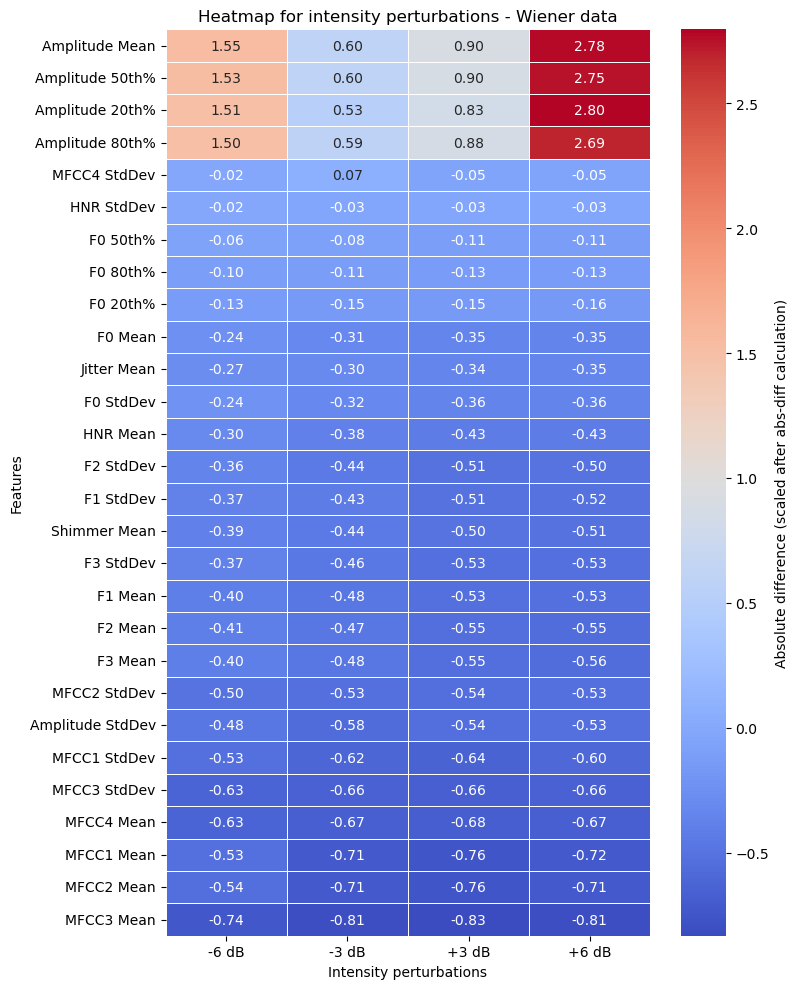

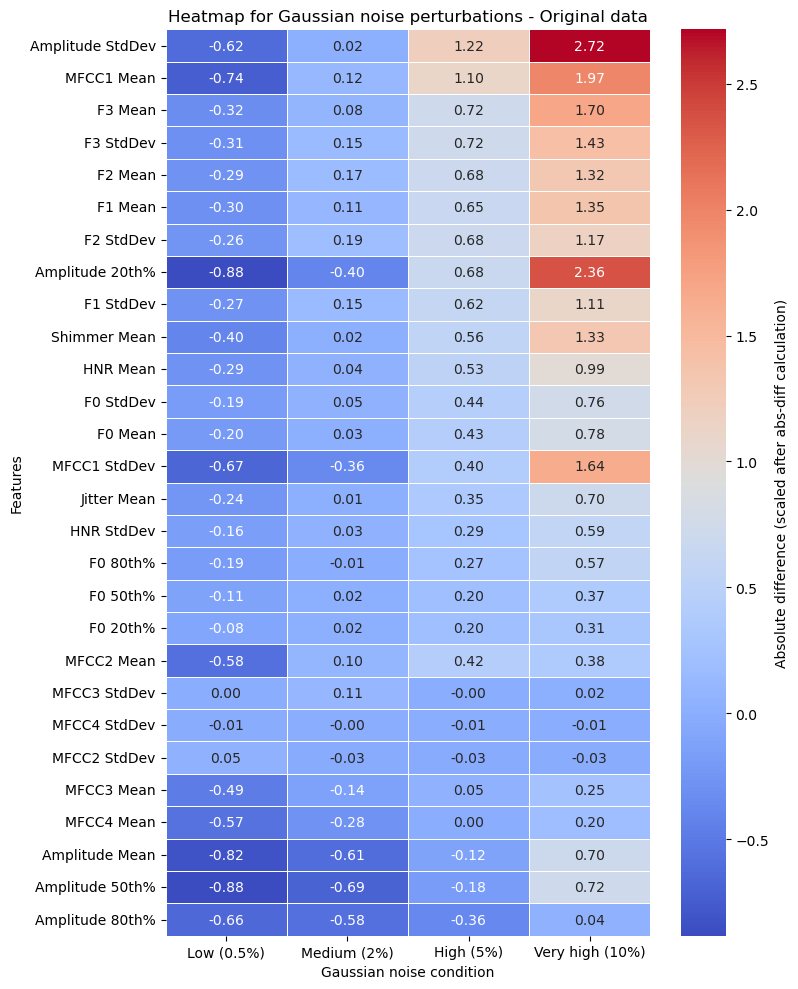

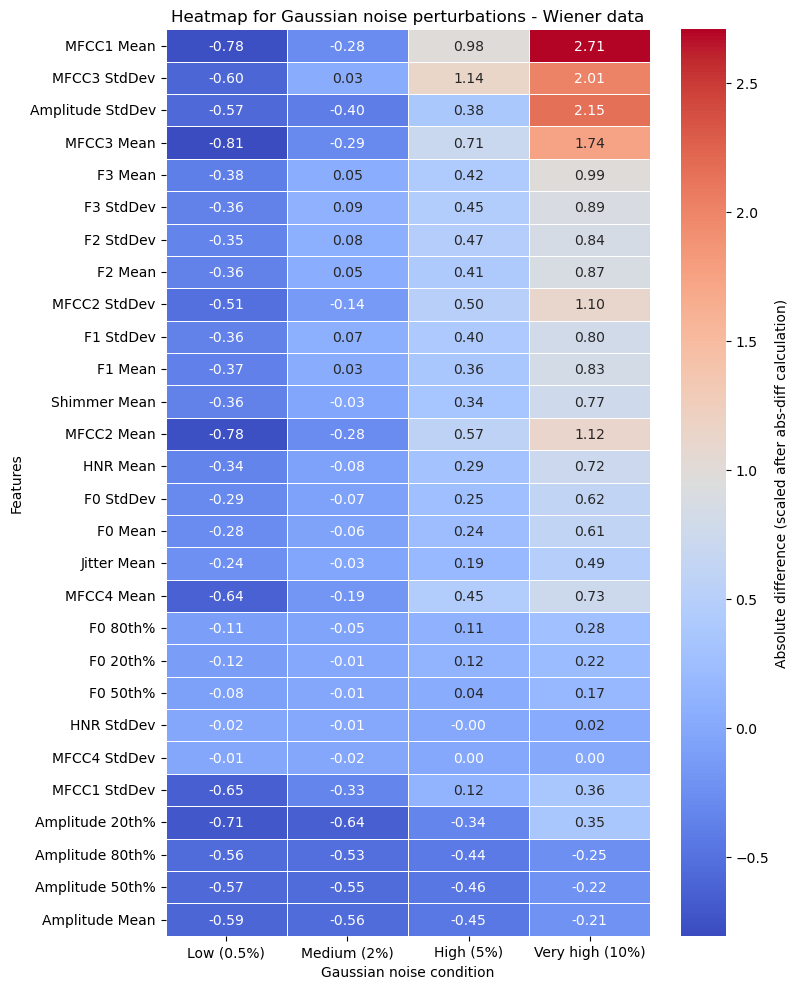

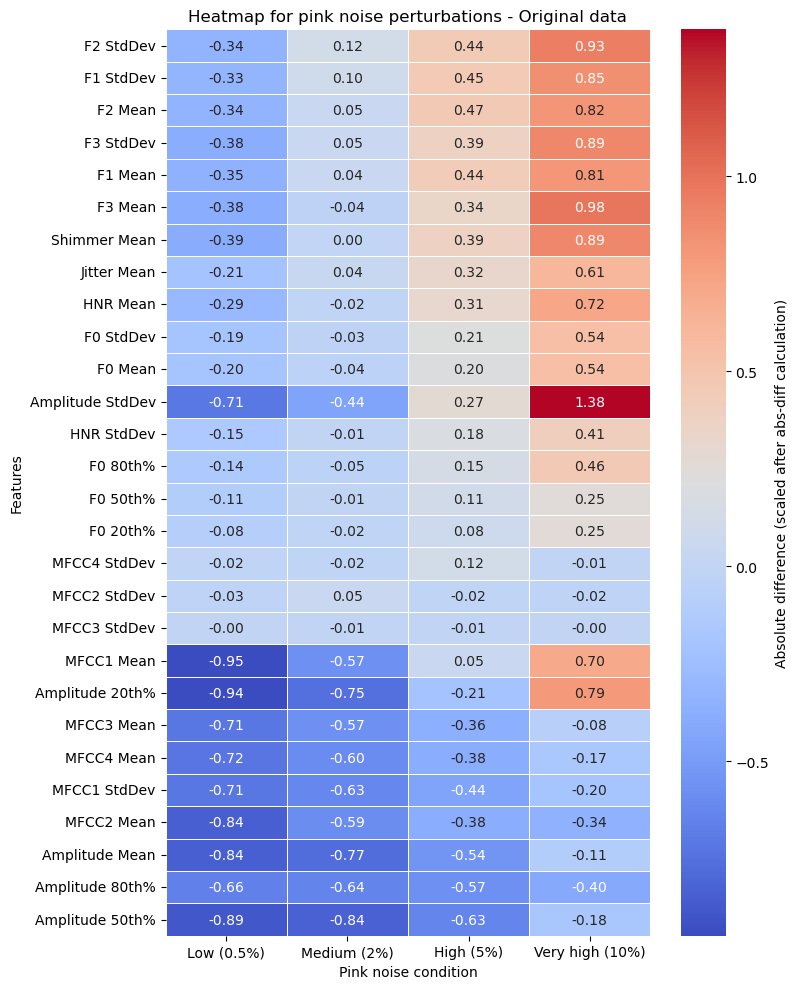

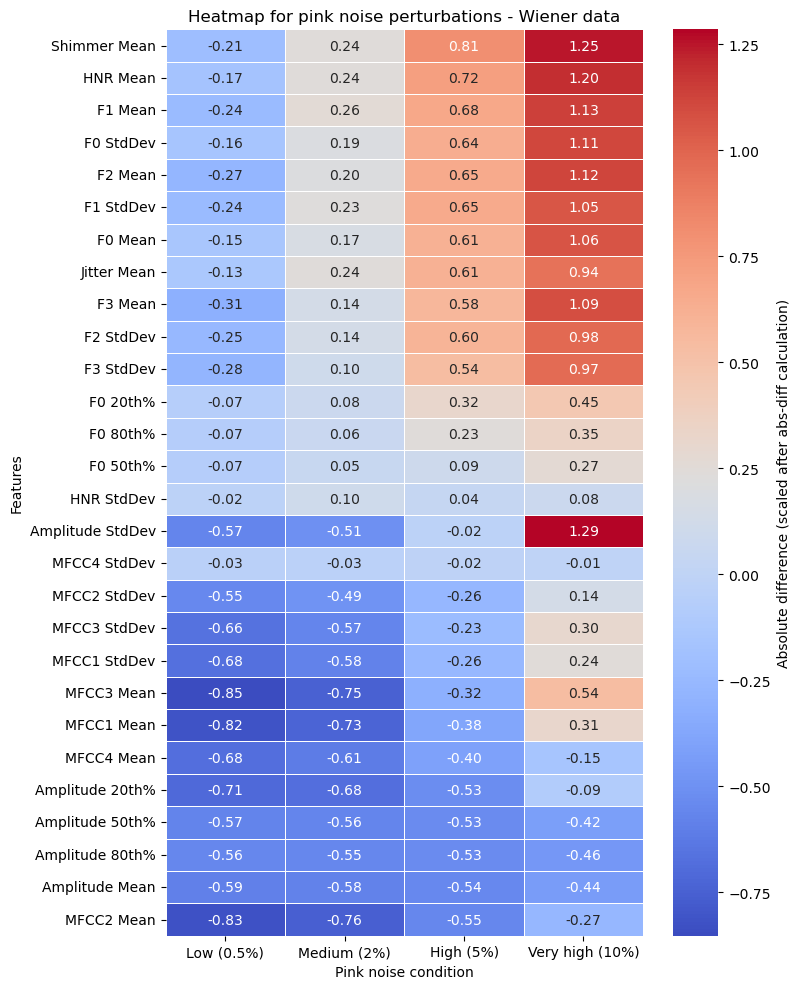

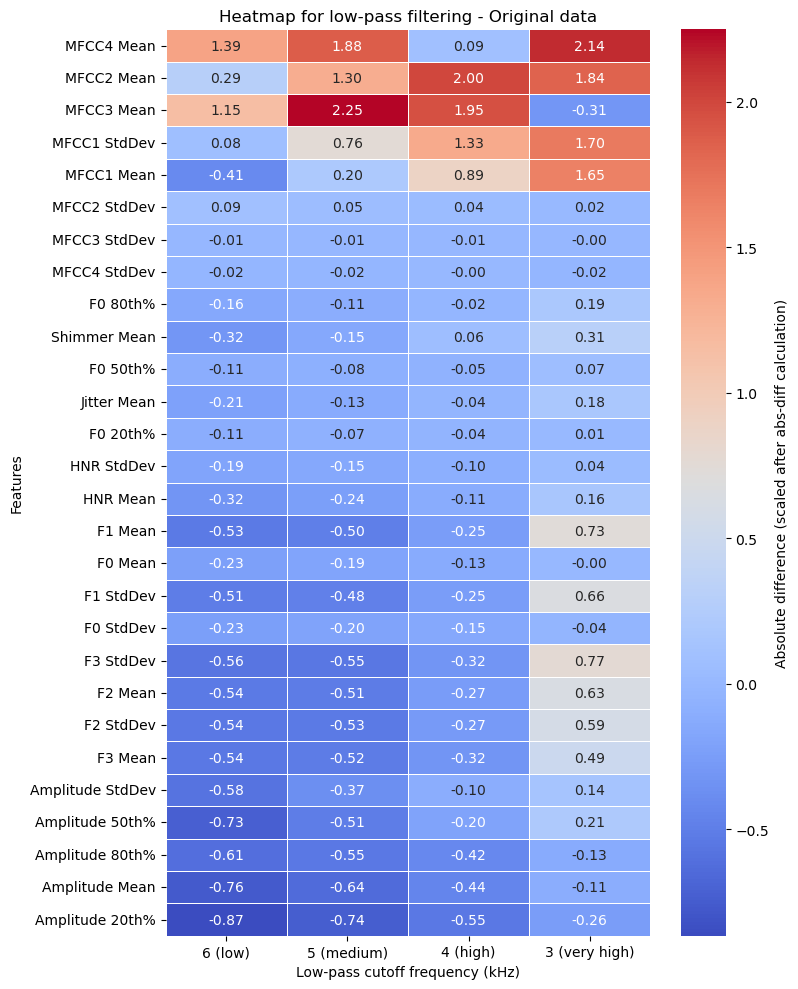

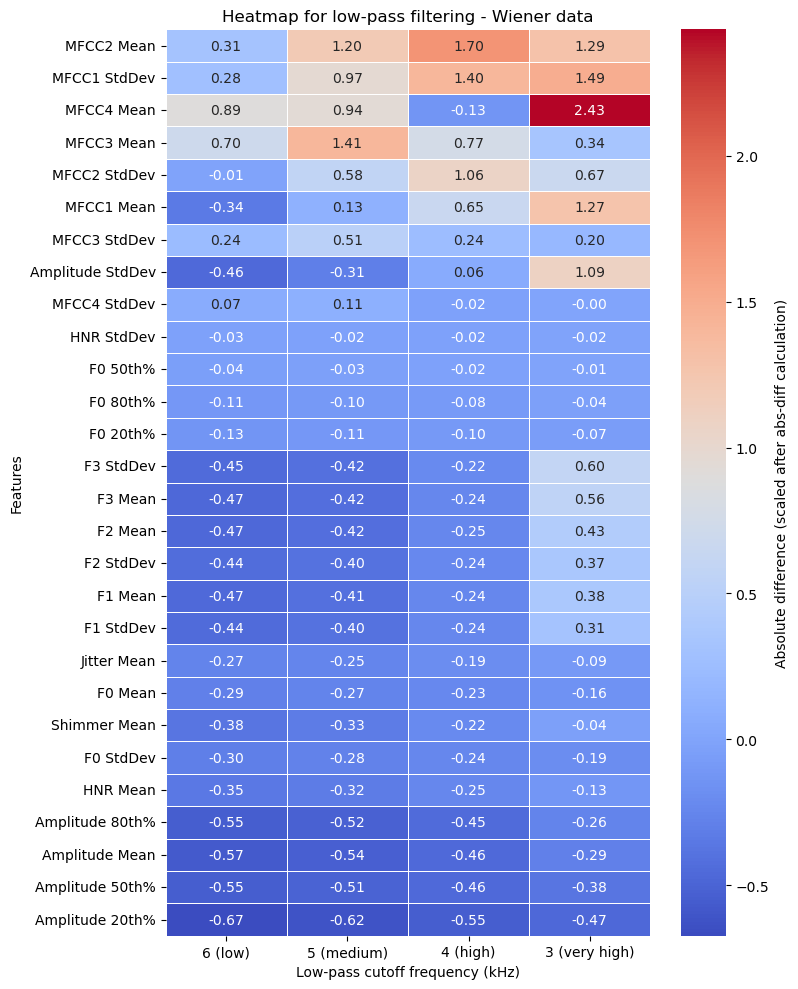

In [6]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Paths
BASE_PATH = Path(r"C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht")

# Selected features
selected_features = {
    "F0 Mean": "F0semitoneFrom27.5Hz_sma3nz_amean",
    "F0 20th%": "F0semitoneFrom27.5Hz_sma3nz_percentile20.0",
    "F0 50th%": "F0semitoneFrom27.5Hz_sma3nz_percentile50.0",
    "F0 80th%": "F0semitoneFrom27.5Hz_sma3nz_percentile80.0",
    "F0 StdDev": "F0semitoneFrom27.5Hz_sma3nz_stddevNorm",
    "F1 Mean": "F1frequency_sma3nz_amean",
    "F1 StdDev": "F1frequency_sma3nz_stddevNorm",
    "F2 Mean": "F2frequency_sma3nz_amean",
    "F2 StdDev": "F2frequency_sma3nz_stddevNorm",
    "F3 Mean": "F3frequency_sma3nz_amean",
    "F3 StdDev": "F3frequency_sma3nz_stddevNorm",
    "HNR Mean": "HNRdBACF_sma3nz_amean",
    "HNR StdDev": "HNRdBACF_sma3nz_stddevNorm",
    "Jitter Mean": "jitterLocal_sma3nz_amean",
    "Amplitude Mean": "loudness_sma3_amean",
    "Amplitude 20th%": "loudness_sma3_percentile20.0",
    "Amplitude 50th%": "loudness_sma3_percentile50.0",
    "Amplitude 80th%": "loudness_sma3_percentile80.0",
    "Amplitude StdDev": "loudness_sma3_stddevNorm",
    "MFCC1 Mean": "mfcc1_sma3_amean",
    "MFCC1 StdDev": "mfcc1_sma3_stddevNorm",
    "MFCC2 Mean": "mfcc2_sma3_amean",
    "MFCC2 StdDev": "mfcc2_sma3_stddevNorm",
    "MFCC3 Mean": "mfcc3_sma3_amean",
    "MFCC3 StdDev": "mfcc3_sma3_stddevNorm",
    "MFCC4 Mean": "mfcc4_sma3_amean",
    "MFCC4 StdDev": "mfcc4_sma3_stddevNorm",
    "Shimmer Mean": "shimmerLocaldB_sma3nz_amean",
}

# =========================
# Configuratie
# =========================
ROBUSTNESS_CONFIG = {
    "intensity": {
        "original": "opensmile_original_pain.csv",
        "wiener": "opensmile_wiener_pain.csv",
        "conditions": {
            "-6 dB": {
                "original": "opensmile_original_intensity_-6dB_pain.csv",
                "wiener": "opensmile_wiener_intensity_-6dB_pain.csv",
            },
            "-3 dB": {
                "original": "opensmile_original_intensity_-3dB_pain.csv",
                "wiener": "opensmile_wiener_intensity_-3dB_pain.csv",
            },
            "+3 dB": {
                "original": "opensmile_original_intensity_3dB_pain.csv",
                "wiener": "opensmile_wiener_intensity_3dB_pain.csv",
            },
            "+6 dB": {
                "original": "opensmile_original_intensity_6dB_pain.csv",
                "wiener": "opensmile_wiener_intensity_6dB_pain.csv",
            },
        },
        "xlabel": "Intensity perturbations",
        "title": "Heatmap for intensity perturbations",
    },
    "gaussian_noise": {
        "original": "opensmile_original_pain.csv",
        "wiener": "opensmile_wiener_pain.csv",
        "conditions": {
            "Low (0.5%)": {
                "original": "opensmile_original_gaussian_low_pain.csv",
                "wiener": "opensmile_wiener_gaussian_low_pain.csv",
            },
            "Medium (2%)": {
                "original": "opensmile_original_gaussian_medium_pain.csv",
                "wiener": "opensmile_wiener_gaussian_medium_pain.csv",
            },
            "High (5%)": {
                "original": "opensmile_original_gaussian_high_pain.csv",
                "wiener": "opensmile_wiener_gaussian_high_pain.csv",
            },
            "Very high (10%)": {
                "original": "opensmile_original_gaussian_very_high_pain.csv",
                "wiener": "opensmile_wiener_gaussian_very_high_pain.csv",
            },
        },
        "xlabel": "Gaussian noise condition",
        "title": "Heatmap for Gaussian noise perturbations",
    },
    "pink_noise": {
        "original": "opensmile_original_pain.csv",
        "wiener": "opensmile_wiener_pain.csv",
        "conditions": {
            "Low (0.5%)": {
                "original": "opensmile_original_pink_low_pain.csv",
                "wiener": "opensmile_wiener_pink_low_pain.csv",
            },
            "Medium (2%)": {
                "original": "opensmile_original_pink_medium_pain.csv",
                "wiener": "opensmile_wiener_pink_medium_pain.csv",
            },
            "High (5%)": {
                "original": "opensmile_original_pink_high_pain.csv",
                "wiener": "opensmile_wiener_pink_high_pain.csv",
            },
            "Very high (10%)": {
                "original": "opensmile_original_pink_very_high_pain.csv",
                "wiener": "opensmile_wiener_pink_very_high_pain.csv",
            },
        },
        "xlabel": "Pink noise condition",
        "title": "Heatmap for pink noise perturbations",
    },
    "lowpass": {
        "original": "opensmile_original_pain.csv",
        "wiener": "opensmile_wiener_pain.csv",
        "conditions": {
            "6 (low)": {
                "original": "opensmile_original_lowpass_low_pain.csv",
                "wiener": "opensmile_wiener_lowpass_low_pain.csv",
            },
            "5 (medium)": {
                "original": "opensmile_original_lowpass_medium_pain.csv",
                "wiener": "opensmile_wiener_lowpass_medium_pain.csv",
            },
            "4 (high)": {
                "original": "opensmile_original_lowpass_high_pain.csv",
                "wiener": "opensmile_wiener_lowpass_high_pain.csv",
            },
            "3 (very high)": {
                "original": "opensmile_original_lowpass_very_high_pain.csv",
                "wiener": "opensmile_wiener_lowpass_very_high_pain.csv",
            },
        },
        "xlabel": "Low-pass cutoff frequency (kHz)",
        "title": "Heatmap for low-pass filtering",
    },
}

EXCLUDE_COLS = ["participant_id", "filename", "file_path", "name"]

# =========================
# Functies
# =========================
def load_and_sort_csv(file_path):
    df = pd.read_csv(file_path)
    return df.sort_values(by=["participant_id", "filename"]).reset_index(drop=True)


def validate_matching_ids(reference_df, comparison_dfs):
    reference_ids = reference_df[["participant_id", "filename"]]

    for name, df in comparison_dfs.items():
        current_ids = df[["participant_id", "filename"]]
        if not reference_ids.equals(current_ids):
            raise ValueError(f"Mismatch in {name}")


def get_selected_feature_cols(df, selected_features_dict):
    missing_features = [col for col in selected_features_dict.values() if col not in df.columns]
    if missing_features:
        raise ValueError(f"Deze selected features ontbreken in de data:\n{missing_features}")
    return list(selected_features_dict.values())


def compute_raw_abs_diff_df(dfs, feature_cols, condition_order, reference_key="original"):
    original_features = dfs[reference_key][feature_cols]
    abs_diff_means = {}

    for condition in condition_order:
        perturbed_features = dfs[condition][feature_cols]
        abs_diff = np.abs(perturbed_features - original_features)
        abs_diff_means[condition] = abs_diff.mean(axis=0)

    heatmap_df = pd.DataFrame(abs_diff_means, index=feature_cols)
    return heatmap_df


def rename_heatmap_index(heatmap_df, selected_features_dict):
    reverse_mapping = {v: k for k, v in selected_features_dict.items()}
    heatmap_df = heatmap_df.copy()
    heatmap_df.index = [reverse_mapping.get(idx, idx) for idx in heatmap_df.index]
    return heatmap_df


def plot_heatmap(
    heatmap_df,
    title,
    xlabel,
    ylabel="Features",
    figsize=(8, 10),
    cbar_label="Scaled absolute difference"
):
    plt.figure(figsize=figsize)
    sns.heatmap(
        heatmap_df,
        cmap="coolwarm",
        linewidths=0.4,
        linecolor="white",
        cbar_kws={"label": cbar_label},
        annot=True,
        fmt=".2f"
    )
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()


def collect_all_abs_diff_rows_for_dataset(
    base_path,
    robustness_config,
    data_type,
    feature_cols
):
    """
    Verzamelt alle raw absolute differences binnen één dataset
    (original of wiener), over alle perturbations en alle condities.
    """
    all_abs_diff_rows = []

    for perturbation_name, config in robustness_config.items():
        original_path = base_path / config[data_type]
        original_df = load_and_sort_csv(original_path)

        for condition_name, paths in config["conditions"].items():
            perturbed_path = base_path / paths[data_type]
            perturbed_df = load_and_sort_csv(perturbed_path)

            validate_matching_ids(
                reference_df=original_df,
                comparison_dfs={condition_name: perturbed_df}
            )

            original_values = original_df[feature_cols].to_numpy()
            perturbed_values = perturbed_df[feature_cols].to_numpy()

            abs_diff = np.abs(perturbed_values - original_values)
            all_abs_diff_rows.append(abs_diff)

    return np.vstack(all_abs_diff_rows)


def fit_absdiff_scaler_for_dataset(
    base_path,
    robustness_config,
    data_type,
    feature_cols
):
    """
    Fit één scaler op alle absolute differences van één dataset.
    """
    all_abs_diff = collect_all_abs_diff_rows_for_dataset(
        base_path=base_path,
        robustness_config=robustness_config,
        data_type=data_type,
        feature_cols=feature_cols
    )

    scaler = StandardScaler()
    scaler.fit(all_abs_diff)
    return scaler


def scale_abs_diff_heatmap_df(raw_abs_diff_df, scaler, feature_cols):
    """
    Schaal de absolute differences met een al gefitte scaler.
    """
    abs_diff_array = raw_abs_diff_df.loc[feature_cols].T.to_numpy()
    abs_diff_scaled = scaler.transform(abs_diff_array)

    scaled_df = pd.DataFrame(
        abs_diff_scaled.T,
        index=feature_cols,
        columns=raw_abs_diff_df.columns
    )

    scaled_df["mean_change"] = scaled_df.mean(axis=1)
    scaled_df = scaled_df.sort_values(by="mean_change", ascending=False)
    scaled_df = scaled_df.drop(columns=["mean_change"])

    return scaled_df


def run_robustness_evaluation_selected_features_absdiff_scaled(
    base_path,
    config,
    data_type,
    selected_features_dict,
    absdiff_scaler,
    save_csv=False
):
    """
    data_type = 'original' of 'wiener'

    Werkwijze:
    1. raw absolute differences berekenen op ongeschaalde features
    2. absolute differences schalen met dataset-specifieke absdiff-scaler
    """
    files = {
        "original": base_path / config[data_type]
    }

    for condition_name, paths in config["conditions"].items():
        files[condition_name] = base_path / paths[data_type]

    dfs = {name: load_and_sort_csv(path) for name, path in files.items()}

    validate_matching_ids(
        reference_df=dfs["original"],
        comparison_dfs={k: v for k, v in dfs.items() if k != "original"}
    )

    feature_cols = get_selected_feature_cols(dfs["original"], selected_features_dict)
    condition_order = list(config["conditions"].keys())

    # Stap 1: raw absolute differences
    raw_abs_diff_df = compute_raw_abs_diff_df(
        dfs=dfs,
        feature_cols=feature_cols,
        condition_order=condition_order,
        reference_key="original"
    )

    # Stap 2: scale op absolute difference
    heatmap_df = scale_abs_diff_heatmap_df(
        raw_abs_diff_df=raw_abs_diff_df,
        scaler=absdiff_scaler,
        feature_cols=feature_cols
    )

    heatmap_df = rename_heatmap_index(heatmap_df, selected_features_dict)

    if save_csv:
        output_name = f"robustness_selected_features_absdiff_scaled_{data_type}_{config['title'].lower().replace(' ', '_')}.csv"
        heatmap_df.to_csv(base_path / output_name)

    plot_heatmap(
        heatmap_df=heatmap_df,
        title=f"{config['title']} - {data_type.capitalize()} data",
        xlabel=config["xlabel"],
        cbar_label="Absolute difference (scaled after abs-diff calculation)"
    )

    return heatmap_df


# =========================
# Scalers fitten
# =========================
feature_cols_reference = list(selected_features.values())

original_absdiff_scaler = fit_absdiff_scaler_for_dataset(
    base_path=BASE_PATH,
    robustness_config=ROBUSTNESS_CONFIG,
    data_type="original",
    feature_cols=feature_cols_reference
)

wiener_absdiff_scaler = fit_absdiff_scaler_for_dataset(
    base_path=BASE_PATH,
    robustness_config=ROBUSTNESS_CONFIG,
    data_type="wiener",
    feature_cols=feature_cols_reference
)

ABSDIFF_SCALERS = {
    "original": original_absdiff_scaler,
    "wiener": wiener_absdiff_scaler,
}

# =========================
# Alles runnen
# =========================
results_selected = {}

for perturbation_name, config in ROBUSTNESS_CONFIG.items():
    results_selected[(perturbation_name, "original")] = run_robustness_evaluation_selected_features_absdiff_scaled(
        base_path=BASE_PATH,
        config=config,
        data_type="original",
        selected_features_dict=selected_features,
        absdiff_scaler=ABSDIFF_SCALERS["original"],
        save_csv=False
    )

    results_selected[(perturbation_name, "wiener")] = run_robustness_evaluation_selected_features_absdiff_scaled(
        base_path=BASE_PATH,
        config=config,
        data_type="wiener",
        selected_features_dict=selected_features,
        absdiff_scaler=ABSDIFF_SCALERS["wiener"],
        save_csv=False
    )

Question 2: “Do the effects of intensity, low-pass, pink noise, and Gaussian perturbations differ between the original dataset and the dataset processed with Wiener filtering?” 
Dus 1 scaler toepassen op original en wiener zodat je die kan vergelijken

RUN_ORIGINAL = True
RUN_WIENER = True

===== Running wiener =====
Scaled abs-difference table saved to: C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht\feature_sensitivity_table_absdiff_original_reference_scaled_wiener.csv
                  Intensity  Gaussian noise  Pink noise  Low-pass filter
F0 Mean           -0.215604        0.179200    0.444479        -0.143904
F0 20th%          -0.107029        0.166347    0.363171        -0.045566
F0 50th%          -0.074824        0.231318    0.373985         0.092047
F0 80th%          -0.215297        0.101104    0.253229        -0.155582
F0 StdDev         -0.217219        0.109671    0.344891        -0.169797
F1 Mean           -0.417551        0.314203    0.572215        -0.101542
F1 StdDev         -0.437581        0.198301    0.379275        -0.191452
F2 Mean           -0.456729        0.219049    0.386256        -0.164520
F2 StdDev         -0.461506        0.185787    0.278441        -0.211273
F3 Mean

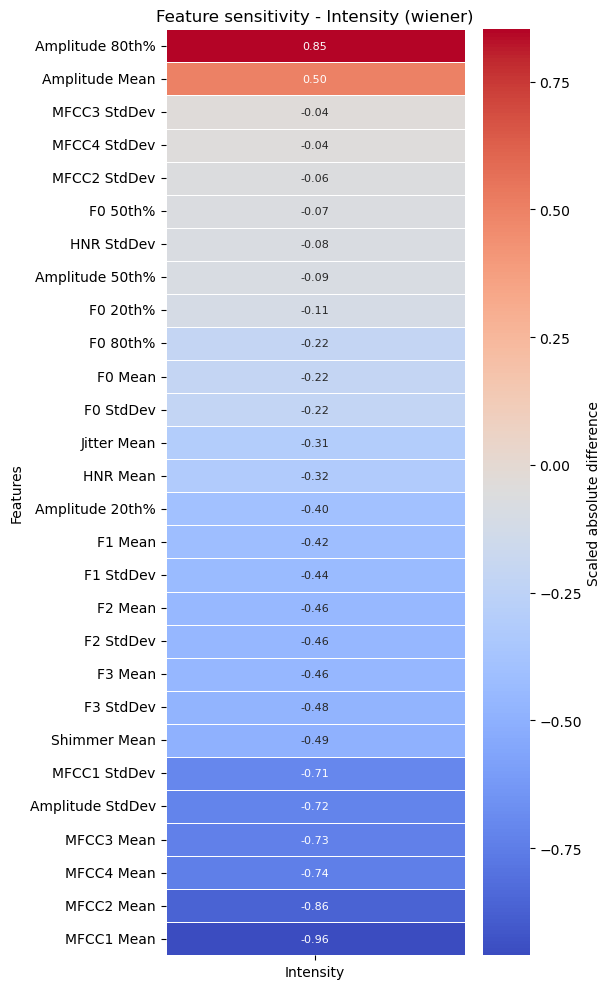

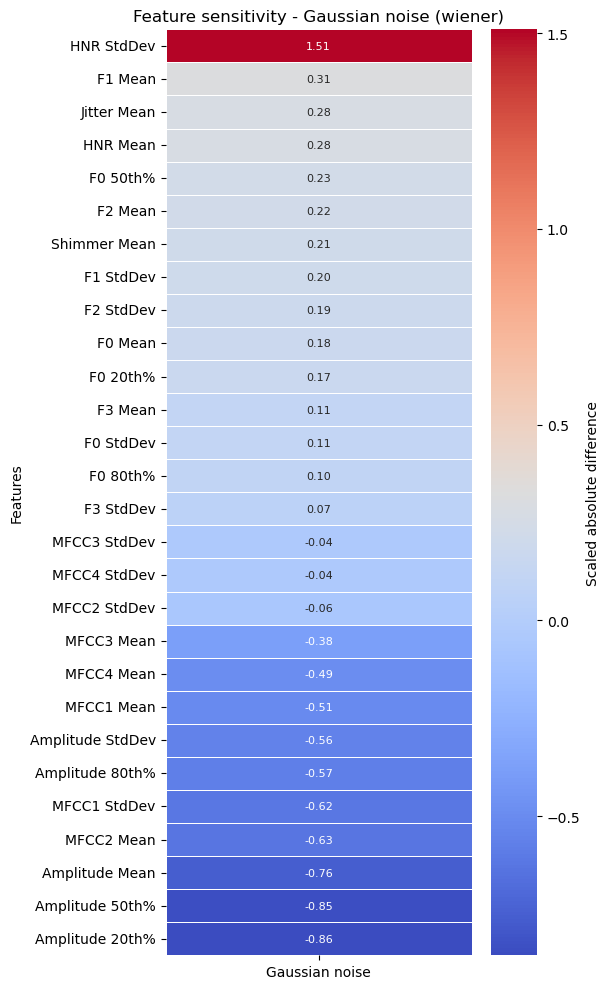

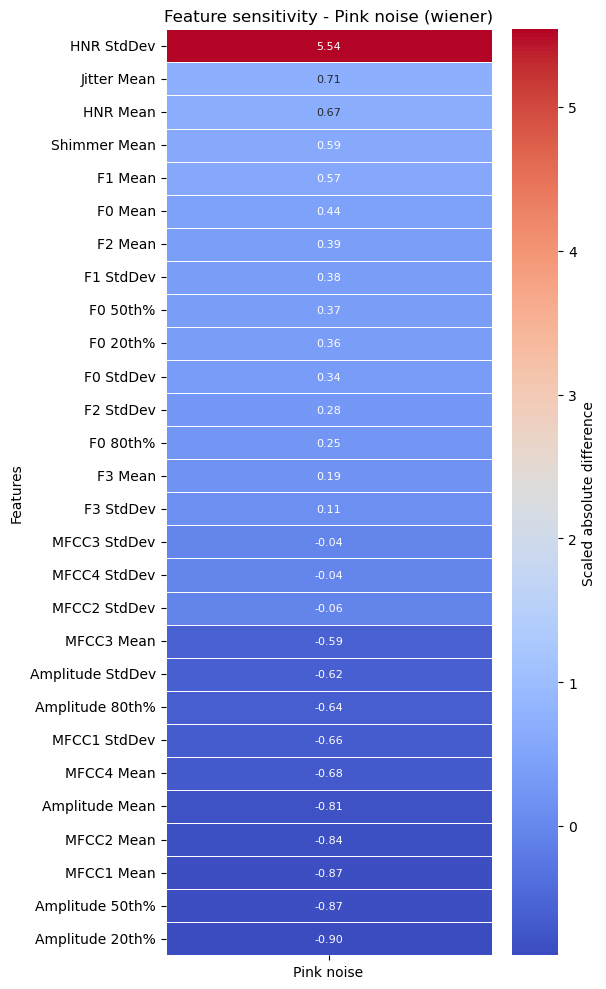

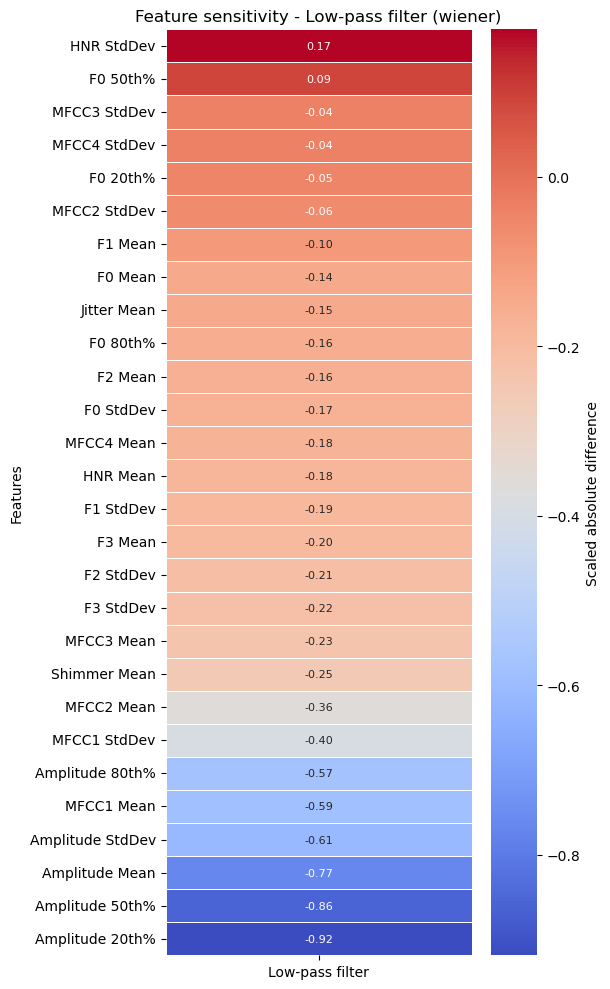

===== Running original =====
Scaled abs-difference table saved to: C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht\feature_sensitivity_table_absdiff_original_reference_scaled_original.csv
                  Intensity  Gaussian noise  Pink noise  Low-pass filter
F0 Mean           -0.247941        0.260122    0.125149        -0.137331
F0 20th%          -0.118301        0.112994    0.057032        -0.051725
F0 50th%          -0.133253        0.119100    0.058576        -0.044423
F0 80th%          -0.238823        0.158241    0.105167        -0.024585
F0 StdDev         -0.241392        0.265763    0.131722        -0.156092
F1 Mean           -0.552137        0.453791    0.235371        -0.137025
F1 StdDev         -0.526883        0.400379    0.270022        -0.143518
F2 Mean           -0.551301        0.472024    0.250270        -0.170993
F2 StdDev         -0.544435        0.442827    0.289944        -0.188335
F3 Mean           -0.549380        0.54526

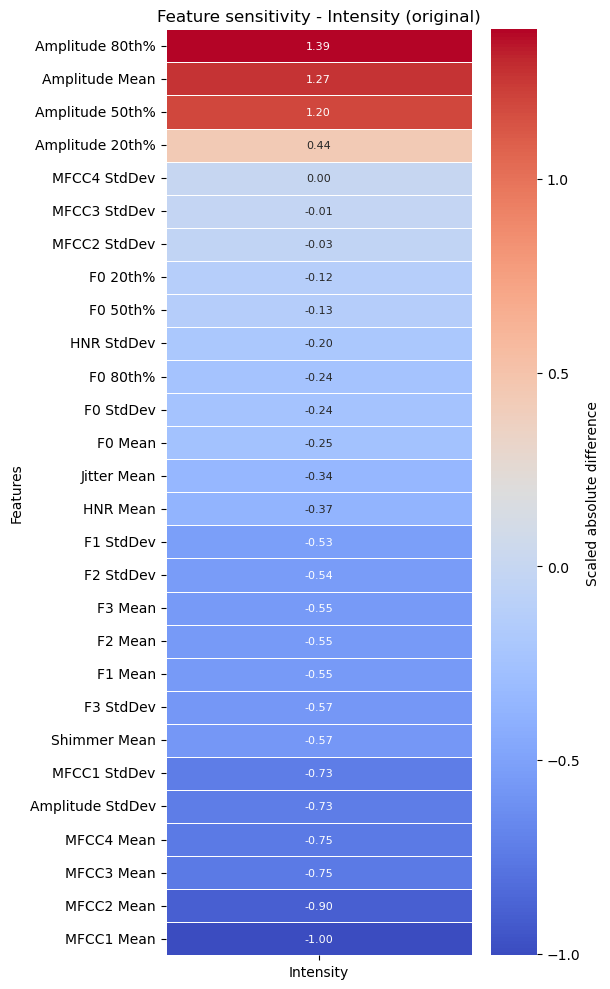

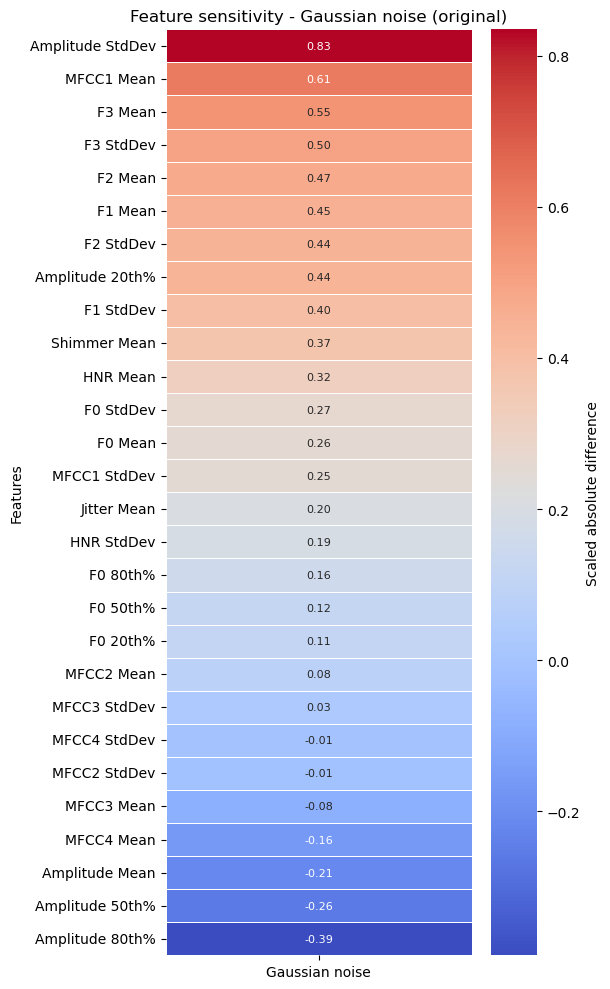

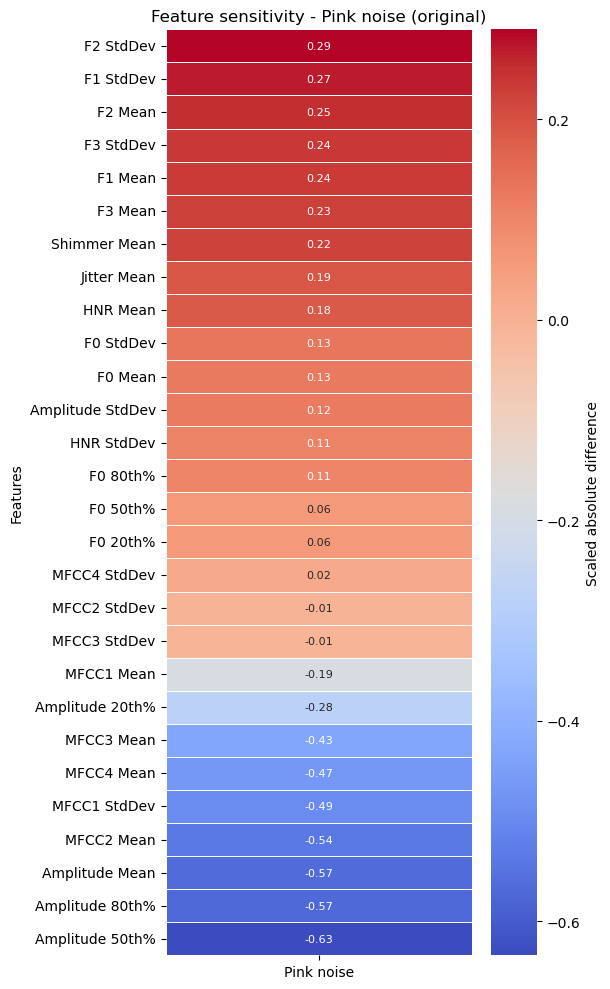

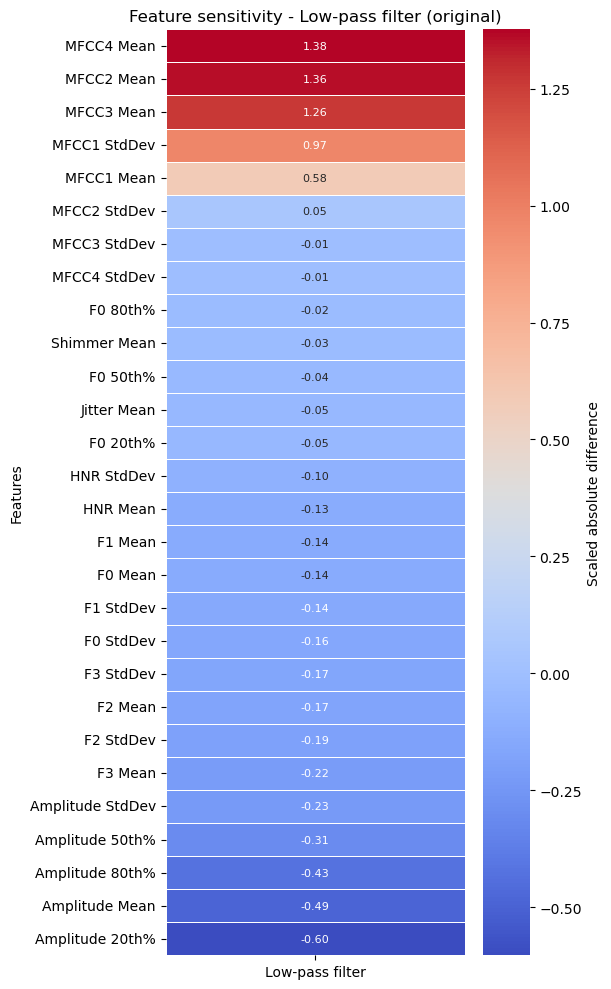

Comparison table saved to: C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht\feature_sensitivity_comparison_absdiff_original_reference_scaled_wiener_minus_original.csv
                  Intensity  Gaussian noise  Pink noise  Low-pass filter
F0 Mean            0.032336       -0.080923    0.319330        -0.006573
F0 20th%           0.011272        0.053354    0.306139         0.006160
F0 50th%           0.058429        0.112218    0.315409         0.136470
F0 80th%           0.023526       -0.057137    0.148062        -0.130997
F0 StdDev          0.024174       -0.156092    0.213170        -0.013705
F1 Mean            0.134586       -0.139588    0.336844         0.035483
F1 StdDev          0.089302       -0.202078    0.109253        -0.047934
F2 Mean            0.094572       -0.252974    0.135986         0.006473
F2 StdDev          0.082930       -0.257040   -0.011503        -0.022938
F3 Mean            0.086032       -0.434631   -0.036418         

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler

# =========================
# Paths + settings
# =========================
BASE_PATH = Path(r"C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht")

RUN_ORIGINAL = True
RUN_WIENER = True

OUTPUT_FILES = {
    "original": BASE_PATH / "feature_sensitivity_table_absdiff_original_reference_scaled_original.csv",
    "wiener": BASE_PATH / "feature_sensitivity_table_absdiff_original_reference_scaled_wiener.csv",
}

RAW_OUTPUT_FILES = {
    "original": BASE_PATH / "feature_sensitivity_table_raw_absdiff_original.csv",
    "wiener": BASE_PATH / "feature_sensitivity_table_raw_absdiff_wiener.csv",
}

HEATMAP_DIR = BASE_PATH / "heatmaps_per_perturbation_absdiff_original_reference_scaled"
HEATMAP_DIR.mkdir(parents=True, exist_ok=True)

SAVE_COMPARISON_TABLE = True
COMPARISON_OUTPUT_FILE = BASE_PATH / "feature_sensitivity_comparison_absdiff_original_reference_scaled_wiener_minus_original.csv"

# =========================
# Selected features
# =========================
selected_features = {
    "F0 Mean": "F0semitoneFrom27.5Hz_sma3nz_amean",
    "F0 20th%": "F0semitoneFrom27.5Hz_sma3nz_percentile20.0",
    "F0 50th%": "F0semitoneFrom27.5Hz_sma3nz_percentile50.0",
    "F0 80th%": "F0semitoneFrom27.5Hz_sma3nz_percentile80.0",
    "F0 StdDev": "F0semitoneFrom27.5Hz_sma3nz_stddevNorm",
    "F1 Mean": "F1frequency_sma3nz_amean",
    "F1 StdDev": "F1frequency_sma3nz_stddevNorm",
    "F2 Mean": "F2frequency_sma3nz_amean",
    "F2 StdDev": "F2frequency_sma3nz_stddevNorm",
    "F3 Mean": "F3frequency_sma3nz_amean",
    "F3 StdDev": "F3frequency_sma3nz_stddevNorm",
    "HNR Mean": "HNRdBACF_sma3nz_amean",
    "HNR StdDev": "HNRdBACF_sma3nz_stddevNorm",
    "Jitter Mean": "jitterLocal_sma3nz_amean",
    "Amplitude Mean": "loudness_sma3_amean",
    "Amplitude 20th%": "loudness_sma3_percentile20.0",
    "Amplitude 50th%": "loudness_sma3_percentile50.0",
    "Amplitude 80th%": "loudness_sma3_percentile80.0",
    "Amplitude StdDev": "loudness_sma3_stddevNorm",
    "MFCC1 Mean": "mfcc1_sma3_amean",
    "MFCC1 StdDev": "mfcc1_sma3_stddevNorm",
    "MFCC2 Mean": "mfcc2_sma3_amean",
    "MFCC2 StdDev": "mfcc2_sma3_stddevNorm",
    "MFCC3 Mean": "mfcc3_sma3_amean",
    "MFCC3 StdDev": "mfcc3_sma3_stddevNorm",
    "MFCC4 Mean": "mfcc4_sma3_amean",
    "MFCC4 StdDev": "mfcc4_sma3_stddevNorm",
    "Shimmer Mean": "shimmerLocaldB_sma3nz_amean",
}

# =========================
# Perturbations
# =========================
PERTURBATION_GROUPS = {}

if RUN_WIENER:
    PERTURBATION_GROUPS["wiener"] = {
        "Intensity": {
            "original": BASE_PATH / "opensmile_wiener_pain.csv",
            "-6": BASE_PATH / "opensmile_wiener_intensity_-6dB_pain.csv",
            "-3": BASE_PATH / "opensmile_wiener_intensity_-3dB_pain.csv",
            "+3": BASE_PATH / "opensmile_wiener_intensity_3dB_pain.csv",
            "+6": BASE_PATH / "opensmile_wiener_intensity_6dB_pain.csv",
        },
        "Gaussian noise": {
            "original": BASE_PATH / "opensmile_wiener_pain.csv",
            "0.5": BASE_PATH / "opensmile_wiener_gaussian_low_pain.csv",
            "2": BASE_PATH / "opensmile_wiener_gaussian_medium_pain.csv",
            "5": BASE_PATH / "opensmile_wiener_gaussian_high_pain.csv",
            "10": BASE_PATH / "opensmile_wiener_gaussian_very_high_pain.csv",
        },
        "Pink noise": {
            "original": BASE_PATH / "opensmile_wiener_pain.csv",
            "0.5": BASE_PATH / "opensmile_wiener_pink_low_pain.csv",
            "2": BASE_PATH / "opensmile_wiener_pink_medium_pain.csv",
            "5": BASE_PATH / "opensmile_wiener_pink_high_pain.csv",
            "10": BASE_PATH / "opensmile_wiener_pink_very_high_pain.csv",
        },
        "Low-pass filter": {
            "original": BASE_PATH / "opensmile_wiener_pain.csv",
            "6000": BASE_PATH / "opensmile_wiener_lowpass_low_pain.csv",
            "5000": BASE_PATH / "opensmile_wiener_lowpass_medium_pain.csv",
            "4000": BASE_PATH / "opensmile_wiener_lowpass_high_pain.csv",
            "3000": BASE_PATH / "opensmile_wiener_lowpass_very_high_pain.csv",
        },
    }

if RUN_ORIGINAL:
    PERTURBATION_GROUPS["original"] = {
        "Intensity": {
            "original": BASE_PATH / "opensmile_original_pain.csv",
            "-6": BASE_PATH / "opensmile_original_intensity_-6dB_pain.csv",
            "-3": BASE_PATH / "opensmile_original_intensity_-3dB_pain.csv",
            "+3": BASE_PATH / "opensmile_original_intensity_3dB_pain.csv",
            "+6": BASE_PATH / "opensmile_original_intensity_6dB_pain.csv",
        },
        "Gaussian noise": {
            "original": BASE_PATH / "opensmile_original_pain.csv",
            "0.5": BASE_PATH / "opensmile_original_gaussian_low_pain.csv",
            "2": BASE_PATH / "opensmile_original_gaussian_medium_pain.csv",
            "5": BASE_PATH / "opensmile_original_gaussian_high_pain.csv",
            "10": BASE_PATH / "opensmile_original_gaussian_very_high_pain.csv",
        },
        "Pink noise": {
            "original": BASE_PATH / "opensmile_original_pain.csv",
            "0.5": BASE_PATH / "opensmile_original_pink_low_pain.csv",
            "2": BASE_PATH / "opensmile_original_pink_medium_pain.csv",
            "5": BASE_PATH / "opensmile_original_pink_high_pain.csv",
            "10": BASE_PATH / "opensmile_original_pink_very_high_pain.csv",
        },
        "Low-pass filter": {
            "original": BASE_PATH / "opensmile_original_pain.csv",
            "6000": BASE_PATH / "opensmile_original_lowpass_low_pain.csv",
            "5000": BASE_PATH / "opensmile_original_lowpass_medium_pain.csv",
            "4000": BASE_PATH / "opensmile_original_lowpass_high_pain.csv",
            "3000": BASE_PATH / "opensmile_original_lowpass_very_high_pain.csv",
        },
    }

if not PERTURBATION_GROUPS:
    raise ValueError("Set RUN_ORIGINAL and/or RUN_WIENER to True.")

# =========================
# Functions
# =========================
def load_and_sort_csv(file_path):
    df = pd.read_csv(file_path)
    return df.sort_values(by=["participant_id", "filename"]).reset_index(drop=True)


def check_alignment(reference_df, comparison_df, label):
    ref_ids = reference_df[["participant_id", "filename"]]
    cmp_ids = comparison_df[["participant_id", "filename"]]

    if not ref_ids.equals(cmp_ids):
        raise ValueError(f"Mismatch in rows for {label}")


def load_all_data(perturbation_groups):
    all_data = {}
    for group_name, files in perturbation_groups.items():
        all_data[group_name] = {}
        for level_label, file_path in files.items():
            all_data[group_name][level_label] = load_and_sort_csv(file_path)
    return all_data


def validate_features_and_alignment(all_data, feature_cols, dataset_name):
    for group_name, dfs in all_data.items():
        clean_df = dfs["original"]

        missing_features = [col for col in feature_cols if col not in clean_df.columns]
        if missing_features:
            raise ValueError(
                f"Missing features in {dataset_name} - {group_name}: {missing_features}"
            )

        for level_label, df in dfs.items():
            if level_label == "original":
                continue
            check_alignment(clean_df, df, f"{dataset_name} - {group_name} - {level_label}")


def collect_all_raw_absdiffs(all_data, feature_cols):
    """
    Verzamel alle ruwe absolute differences binnen één dataset.
    Output shape: (n_total_rows_over_all_levels, n_features)
    """
    all_absdiff_arrays = []

    for group_name, dfs in all_data.items():
        clean_values = dfs["original"][feature_cols].to_numpy()

        for level_label, df in dfs.items():
            if level_label == "original":
                continue

            perturbed_values = df[feature_cols].to_numpy()
            abs_diff = np.abs(clean_values - perturbed_values)
            all_absdiff_arrays.append(abs_diff)

    return np.vstack(all_absdiff_arrays)


def fit_original_absdiff_scaler(original_perturbation_groups, feature_cols):
    """
    Fit één scaler op ALLE raw absolute differences van Original.
    Die scaler wordt later gebruikt voor zowel Original als Wiener.
    """
    original_all_data = load_all_data(original_perturbation_groups)
    validate_features_and_alignment(original_all_data, feature_cols, "original")

    stacked_original_absdiffs = collect_all_raw_absdiffs(original_all_data, feature_cols)

    scaler = StandardScaler()
    scaler.fit(stacked_original_absdiffs)
    return scaler


def run_sensitivity_analysis_absdiff_original_reference(
    dataset_name,
    perturbation_groups,
    output_file,
    raw_output_file,
    reference_absdiff_scaler
):
    """
    1. Bereken raw absolute differences op ongeschaalde features
    2. Gebruik één scaler die ALLEEN is gefit op Original absolute differences
    3. Pas die scaler toe op zowel Original als Wiener absolute differences
    4. Bereken gemiddelde score per feature per perturbation group
    """
    feature_cols = list(selected_features.values())

    all_data = load_all_data(perturbation_groups)
    validate_features_and_alignment(all_data, feature_cols, dataset_name)

    results_scaled = pd.DataFrame(
        index=selected_features.keys(),
        columns=perturbation_groups.keys(),
        dtype=float
    )

    results_raw = pd.DataFrame(
        index=selected_features.keys(),
        columns=perturbation_groups.keys(),
        dtype=float
    )

    for group_name, dfs in all_data.items():
        clean_values = dfs["original"][feature_cols].to_numpy()

        for i, (feature_name, feature_col) in enumerate(selected_features.items()):
            raw_level_scores = []
            scaled_level_scores = []

            for level_label, df in dfs.items():
                if level_label == "original":
                    continue

                perturbed_values = df[feature_cols].to_numpy()

                # Ruwe absolute difference
                abs_diff_raw = np.abs(clean_values - perturbed_values)

                # Schalen met scaler die alleen op Original absdiffs is gefit
                abs_diff_scaled = reference_absdiff_scaler.transform(abs_diff_raw)

                raw_level_scores.append(abs_diff_raw[:, i].mean())
                scaled_level_scores.append(abs_diff_scaled[:, i].mean())

            results_raw.loc[feature_name, group_name] = np.mean(raw_level_scores)
            results_scaled.loc[feature_name, group_name] = np.mean(scaled_level_scores)

    results_scaled.to_csv(output_file)
    results_raw.to_csv(raw_output_file)

    print(f"Scaled abs-difference table saved to: {output_file}")
    print(results_scaled)
    print()

    print(f"Raw abs-difference table saved to: {raw_output_file}")
    print(results_raw)
    print()

    return results_scaled, results_raw


def save_heatmaps(results_df, dataset_name, heatmap_dir, suffix=""):
    dataset_heatmap_dir = heatmap_dir / dataset_name
    dataset_heatmap_dir.mkdir(parents=True, exist_ok=True)

    for group_name in results_df.columns:
        heatmap_data = results_df[[group_name]].copy()
        heatmap_data = heatmap_data.sort_values(by=group_name, ascending=False)

        plt.figure(figsize=(6, 10))
        sns.heatmap(
            heatmap_data,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            cbar_kws={"label": "Scaled absolute difference"},
            linewidths=0.5,
            cbar=True,
            annot_kws={"size": 8}
        )

        plt.title(f"Feature sensitivity - {group_name} ({dataset_name})")
        plt.xlabel("")
        plt.ylabel("Features")
        plt.tight_layout()

        filename = f"heatmap_{group_name.replace(' ', '_')}_{dataset_name}{suffix.replace(' ', '_')}.png"
        plt.savefig(dataset_heatmap_dir / filename, dpi=300)
        plt.show()
        plt.close()


def save_original_vs_wiener_comparison(all_results, output_file):
    if "original" not in all_results or "wiener" not in all_results:
        return

    comparison_df = all_results["wiener"] - all_results["original"]
    comparison_df.to_csv(output_file)

    print(f"Comparison table saved to: {output_file}")
    print(comparison_df)
    print()


# =========================
# Run
# =========================
all_results_scaled = {}
all_results_raw = {}

print("RUN_ORIGINAL =", RUN_ORIGINAL)
print("RUN_WIENER =", RUN_WIENER)
print()

feature_cols = list(selected_features.values())

# ÉÉN scaler, gefit op alle absolute differences van Original
original_reference_absdiff_scaler = fit_original_absdiff_scaler(
    original_perturbation_groups=PERTURBATION_GROUPS["original"],
    feature_cols=feature_cols
)

for dataset_name, perturbation_groups in PERTURBATION_GROUPS.items():
    print(f"===== Running {dataset_name} =====")

    scaled_results, raw_results = run_sensitivity_analysis_absdiff_original_reference(
        dataset_name=dataset_name,
        perturbation_groups=perturbation_groups,
        output_file=OUTPUT_FILES[dataset_name],
        raw_output_file=RAW_OUTPUT_FILES[dataset_name],
        reference_absdiff_scaler=original_reference_absdiff_scaler
    )

    all_results_scaled[dataset_name] = scaled_results
    all_results_raw[dataset_name] = raw_results

    save_heatmaps(
        results_df=scaled_results,
        dataset_name=dataset_name,
        heatmap_dir=HEATMAP_DIR,
        suffix="_absdiff_original_reference_scaled"
    )

if SAVE_COMPARISON_TABLE:
    save_original_vs_wiener_comparison(all_results_scaled, COMPARISON_OUTPUT_FILE)

Question 3 --> nog doen!